In [11]:
# 라이브러리 호출
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
# 버트 사용을 위한 라이브러리
from pytorch_transformers import BertTokenizer, BertForSequenceClassification
import torch.nn.functional as F
import torch.optim as optim
# 모델 평가를 위해 사용
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [12]:
# 데이터셋 불러오기
train_df = pd.read_csv('../data/training.txt', sep='\t')
valid_df = pd.read_csv('../data/validing.txt', sep='\t')
test_df = pd.read_csv('../data/testing.txt', sep='\t')

In [13]:
# 불러온 데이터셋 중 일부만 사용
train_df = train_df.sample(frac=0.1, random_state=500)
valid_df = valid_df.sample(frac=0.1, random_state=500)
test_df = test_df.sample(frac=0.1, random_state=500)

In [14]:
# 데이터셋 생성
class Datasets(Dataset):

    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        text = self.df.iloc[idx, 1]
        label = self.df.iloc[idx, 2]
        return text, label

In [15]:
# 데이터셋의 데이터를 데이터로더로 전달
train_dataset = Datasets(train_df)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=0)

valid_dataset = Datasets(valid_df)
valid_loader = DataLoader(valid_dataset, batch_size=2, shuffle=True, num_workers=0)

test_dataset = Datasets(test_df)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=True, num_workers=0)

In [16]:
# 버트 토크나이저 내려받기
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased')
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [25]:
# 최적화 모델 저장
def save_checkpoint(save_path, model, valid_loss):
    """모델 평가를 위해 훈련 과정을 저장"""
    if save_path == None:
        return
    state_dict = {'model_state_dict': model.state_dict(),
                  'valid_loss': valid_loss}
    torch.save(state_dict, save_path)
    print(f'Model saved to ==> {save_path}')

def load_checkpoint(load_path, model):
    """save_checkpoint 함수에서 저장된 모델을 가져옵니다."""
    if load_path == None:
        return
    state_dict = torch.load(load_path, map_location=device)
    print(f'Model laoded from <== {load_path}')
    model.load_state_dict(state_dict['model_state_dict'])
    return state_dict['valid_loss']
    
def save_metrics(save_path, train_loss_list, valid_loss_list, global_steps_list):
    """훈련, 검증에 대한 오차와 에포크를 저장"""
    if save_path == None:
        return
    state_dict = {
        'train_loss_list': train_loss_list,
        'valid_loss_list': valid_loss_list,
        'global_steps_list': global_steps_list,
        }
    torch.save(state_dict, save_path)
    print(f'Model saved to ==> {save_path}')

def load_metrics(load_path):
    """save_metrics에 저장해 둔 정보를 불러옵니다."""
    if load_path == None:
        return
    state_dict = torch.load(load_path, map_location=device)
    print(f'Model loaded from <== {load_path}')
    return state_dict['train_loss_list'], state_dict['valid_loss_list'], state_dict['global_steps_list']

In [18]:
# 모델 훈련 함수 정의
def train(model, optimizer, criterion=nn.BCELoss(), num_epochs=5, eval_every=len(train_loader)//2, best_valid_loss=float('Inf')):
    # 영화 리뷰는 좋고 나쁨만 있으므로 BinaryCrossEntropy(BCELoss)를 사용
    # 에포크는 5
    total_correct = 0.0
    total_len = 0.0
    running_loss = 0.0
    valid_running_loss = 0.0
    global_step = 0
    train_loss_list = []
    valid_loss_list = []
    global_steps_list = []

    # 모델 훈련
    model.train()
    for epoch in range(num_epochs):
        for text, label in train_loader:
            optimizer.zero_grad()
            # [CLS], [SEP]과 같은 특수 토큰을 추가하라
            # encoded_list = [[101, 2023, 2003, 1037, 2742, 102], [101, 2027, 2215, 2000, 2031, 102]]
            # 해당 입력 텍스트의 토큰 ID를 나타내는 정수로 구성되어 있음
            encoded_list = [tokenizer.encode(t, add_special_tokens=True) for t in text]
            # 인코딩 결과에 제로패딩을 적용
            padded_list = [e + [0] * (512 - len(e)) for e in encoded_list]
            sample = torch.tensor(padded_list)
            sample, labels = sample.to(device), label.to(device)
            # labels = torch.tensor(label)
            # 파이토치에서는 위보다는 아래의 코드를 더 추천함
            # labels = label.to(device)
            outputs = model(sample, labels=labels)
            loss, logits = outputs

            # 이제 소프트맥스 함수에서 암시적 차원 지정이 허용되지 않음
            # pred = torch.argmax(F.softmax(logits), dim=1)
            pred = torch.argmax(F.softmax(logits, dim=1), dim=1)
            # 예측 값이 실제 라벨과 일치하면 True, 그렇지 않으면 False를 가지는 labels와 동일한 형태의 텐서 생성
            correct = pred.eq(labels)
            total_correct += correct.sum().item()
            total_len += len(labels)
            running_loss += loss.item()
            loss.backward()
            optimizer.step()
            global_step += 1

            # 모델 평가
            if global_step % eval_every == 0:
                model.eval()
                with torch.no_grad():
                    for text, label in valid_loader:
                        encoded_list = [tokenizer.encode(t, add_special_tokens=True) for t in text]
                        padded_list = [e + [0] * (512 - len(e)) for e in encoded_list]
                        sample = torch.tensor(padded_list)
                        sample, labels = sample.to(device), label.to(device)
                        # labels = torch.tensor(label)
                        outputs = model(sample, labels=labels)
                        loss, logits = outputs
                        valid_running_loss = loss.item()

                    average_train_loss = running_loss / eval_every
                    average_valid_loss = valid_running_loss / len(valid_loader)
                    train_loss_list.append(average_train_loss)
                    valid_loss_list.append(average_valid_loss)
                    global_steps_list.append(global_step)
                    
                    running_loss = 0.0
                    valid_running_loss = 0.0
                    model.train()

                    print(f'Epoch [{epoch+1}/{num_epochs}], Step [{global_step}/{num_epochs*len(train_loader)}], Train Loss: {average_train_loss:.4f}, Valid Loss: {average_valid_loss:.4f}')

                    if best_valid_loss > average_valid_loss:
                        best_valid_loss = average_valid_loss
                        # 오차가 작아지면 모델 저장
                        save_checkpoint('../data/model.pt', model, best_valid_loss)
                        # 평가에 사용된 훈련 오차, 검증 오차, 에포크(스텝)을 저장
                        save_metrics('../data/metrics.pt', train_loss_list, valid_loss_list, global_steps_list)
    # 최종으로 사용된 훈련 오차, 검증 오차, 에포크(스텝)를 저장
    save_metrics('../data/metrics.pt', train_loss_list, valid_loss_list, global_steps_list)
    print('훈련 종료!')

In [19]:
# 모델의 파라미터(옵티마이저) 미세 조정 및 모델 훈련
# 아담 옵티마이저와 적절한 학습률로 버트 모델을 미세 조정합니다.
optimizer = optim.Adam(model.parameters(), lr=2e-5)
# 모델을 학습시킵니다.
train(model=model, optimizer=optimizer)

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_4760\619453547.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(label)
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_4760\619453547.py:28: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  pred = torch.argmax(F.softmax(logits), dim=1)
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_4760\619453547.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(label)


Epoch [1/5], Step [510/5100], Train Loss: 0.7067, Valid Loss: 0.0006
Model saved to ==> ../data/model.pt
Model saved to ==> ../data/metrics.pt
Epoch [1/5], Step [1020/5100], Train Loss: 0.7102, Valid Loss: 0.0007
Epoch [2/5], Step [1530/5100], Train Loss: 0.7057, Valid Loss: 0.0007
Epoch [2/5], Step [2040/5100], Train Loss: 0.6989, Valid Loss: 0.0006
Epoch [3/5], Step [2550/5100], Train Loss: 0.7029, Valid Loss: 0.0007
Epoch [3/5], Step [3060/5100], Train Loss: 0.7029, Valid Loss: 0.0006
Model saved to ==> ../data/model.pt
Model saved to ==> ../data/metrics.pt
Epoch [4/5], Step [3570/5100], Train Loss: 0.6976, Valid Loss: 0.0006
Epoch [4/5], Step [4080/5100], Train Loss: 0.6994, Valid Loss: 0.0007
Epoch [5/5], Step [4590/5100], Train Loss: 0.6992, Valid Loss: 0.0008
Epoch [5/5], Step [5100/5100], Train Loss: 0.6994, Valid Loss: 0.0006
Model saved to ==> ../data/metrics.pt
훈련 종료!


Model loaded from <== ../data/metrics.pt


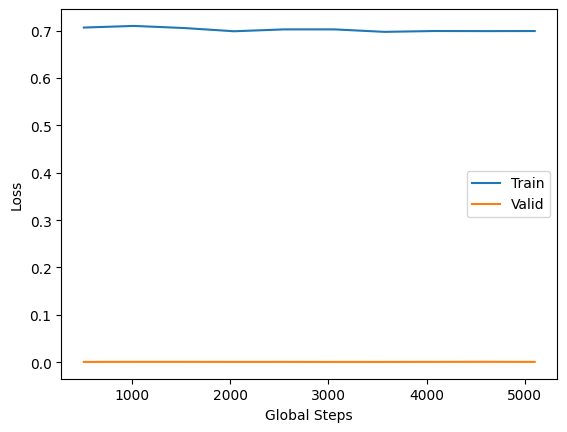

In [22]:
# 오차 정보를 그래프로 확인
# 최종으로 저장된 모델을 불러옵니다.
train_loss_list, valid_loss_list, global_steps_list = load_metrics('../data/metrics.pt')

# 훈련 데이터셋에 대한 오차
plt.plot(global_steps_list, train_loss_list, label='Train')
# 검증 데이터셋에 대한 오차
plt.plot(global_steps_list, valid_loss_list, label='Valid')
plt.xlabel('Global Steps')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [23]:
# 모델 평가 함수 정의
def evaluate(model, test_loader):
    y_pred = []
    y_true = []

    # 테스트 데이터셋으로 모델 평가
    model.eval()
    with torch.no_grad():
        for text, label in test_loader:
            encoded_list = [tokenizer.encode(t, add_special_tokens=True) for t in text]
            padded_list = [e + [0] * (512-len(e)) for e in encoded_list]
            sample = torch.tensor(padded_list)
            sample, label = sample.to(device), label.to(device)
            labels = torch.tensor(label)
            # 모델은 첫 번째 요소로 손실, 두 번째 요소로 로짓을 포함하는 튜플 반환
            output = model(sample, labels=labels)
            _, output = output
            y_pred.extend(torch.argmax(output, 1).tolist())
            y_true.extend(labels.tolist())
        
    print('Classification 결과:')
    # 소수점 자리 수는 4자 이내로
    print(classification_report(y_true, y_pred, labels=[1, 0], digits=4))
    
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax=ax, cmap='Blues', fmt='d')
    ax.set_title('Confusion Matrix')
    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('True Labels')
    ax.xaxis.set_ticklabels(['0', '1'])
    ax.yaxis.set_ticklabels(['0', '1'])

Model laoded from <== ../data/model.pt


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_4760\588452377.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(label)


Classification 결과:
              precision    recall  f1-score   support

           1     0.0000    0.0000    0.0000       558
           0     0.4909    1.0000    0.6585       538

    accuracy                         0.4909      1096
   macro avg     0.2454    0.5000    0.3293      1096
weighted avg     0.2410    0.4909    0.3232      1096



c:\Users\SSAFY\anaconda3\envs\torch_book\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SSAFY\anaconda3\envs\torch_book\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SSAFY\anaconda3\envs\torch_book\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

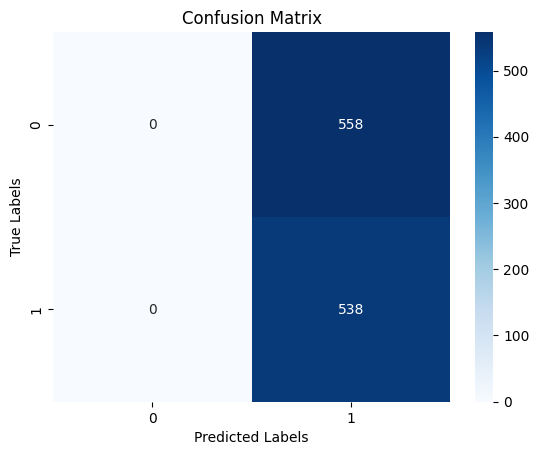

In [26]:
# 모델 평가
best_model = model.to(device)
load_checkpoint('../data/model.pt', best_model)
evaluate(best_model, test_loader)